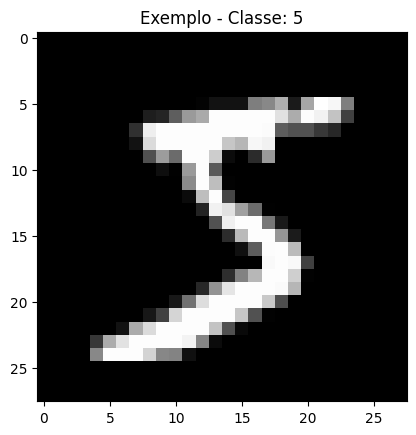

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


375/375 - 2s - 6ms/step - accuracy: 0.8953 - loss: 0.3712 - val_accuracy: 0.9455 - val_loss: 0.1865
Epoch 2/15
375/375 - 3s - 7ms/step - accuracy: 0.9551 - loss: 0.1526 - val_accuracy: 0.9647 - val_loss: 0.1309
Epoch 3/15
375/375 - 2s - 5ms/step - accuracy: 0.9681 - loss: 0.1071 - val_accuracy: 0.9672 - val_loss: 0.1142
Epoch 4/15
375/375 - 2s - 6ms/step - accuracy: 0.9750 - loss: 0.0820 - val_accuracy: 0.9715 - val_loss: 0.0984
Epoch 5/15
375/375 - 2s - 6ms/step - accuracy: 0.9808 - loss: 0.0632 - val_accuracy: 0.9703 - val_loss: 0.1003
Epoch 6/15
375/375 - 1s - 3ms/step - accuracy: 0.9845 - loss: 0.0512 - val_accuracy: 0.9737 - val_loss: 0.0917
Epoch 7/15
375/375 - 1s - 4ms/step - accuracy: 0.9881 - loss: 0.0404 - val_accuracy: 0.9728 - val_loss: 0.0972
Epoch 8/15
375/375 - 2s - 7ms/step - accuracy: 0.9897 - loss: 0.0330 - val_accuracy: 0.9741 - val_loss: 0.0954
Epoch 9/15
375/375 - 2s - 7ms/step - accuracy: 0.9921 - loss: 0.0260 - val_accuracy: 0.9737 - val_loss: 0.0930
Epoch 10/15


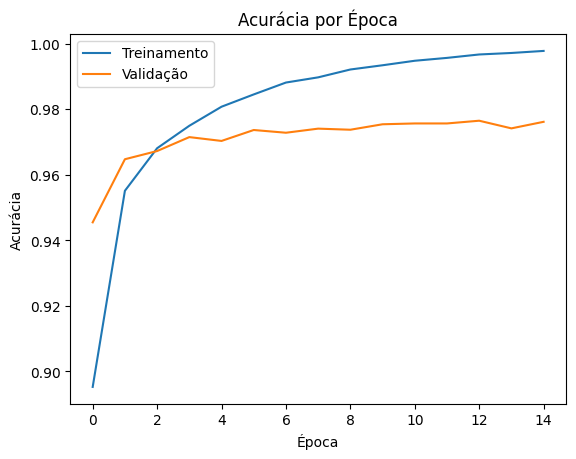

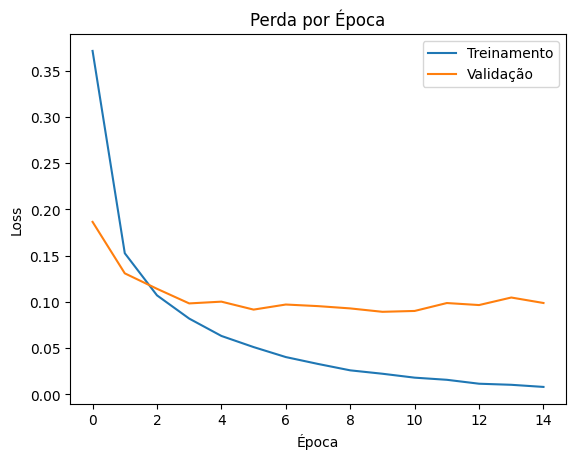

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/tmp/ipython-input-2-1935313753.py:86: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.savefig("imagens/matriz_confusao.png")
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


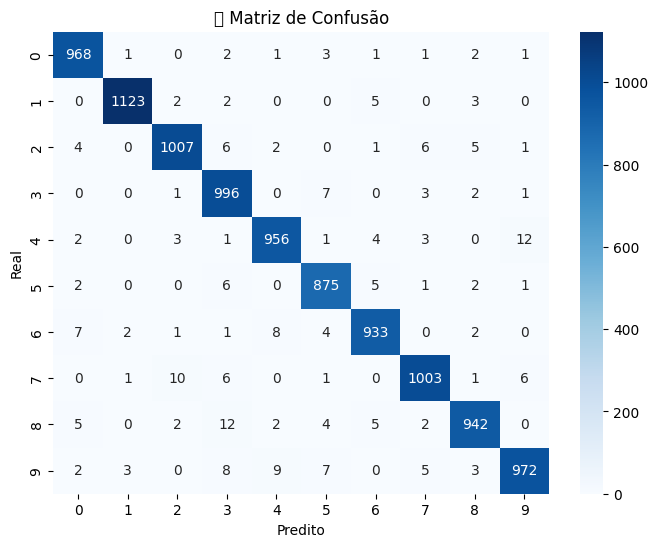

In [2]:
# 🔧 Importações principais
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import os

# 📥 Carregamento do dataset MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 🔍 Visualização de exemplo
plt.imshow(x_train[0], cmap='gray')
plt.title(f'Exemplo - Classe: {y_train[0]}')
plt.show()

# ⚙️ Pré-processamento
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

# 🧠 Modelo: Rede Neural Densa
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 🏁 Treinamento do modelo
history = model.fit(x_train, y_train_cat,
                    validation_split=0.2,
                    epochs=15, batch_size=128,
                    verbose=2)

# 🧪 Avaliação final
loss, acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Acurácia no teste: {acc:.2%}")
print(f"Loss: {loss:.4f}")

# Cria o diretório para salvar as imagens
os.makedirs('imagens', exist_ok=True)

# 📈 Gráfico da Acurácia
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.savefig('imagens/acuracia.png')  # salva o gráfico
plt.show()

# 📉 Gráfico da Perda
plt.plot(history.history['loss'], label='Treinamento')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Perda por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.savefig('imagens/loss.png')  # salva o gráfico
plt.show()

# 🎯 Matriz de confusão (extra)
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

conf_matrix = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("🔢 Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.savefig("imagens/matriz_confusao.png")
plt.show()